<h1 style="color:#89CFF0"> Predicting User Retention </h1>
<h3 style="color:#89CFF0">Objective:</h3> Predict whether users will continue using a service based on usage data.

#### <span style="color:#89CFF0">Dataset Used</span>


The data set used in this project are the customer_churn_dataset-testing-master.csv and customer_churn_dataset-training-master.csv uploaded by Muhammad Shahid Azeem under Customer Churn Dataset. The link to the used data set is as follows:

[CSV FILE](https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset)

The dataset contains 12 feature columns. Those are as follows:
- CustomerID: A unique identifier for each customer
- Age: The age of the customer
- Gender: Gender of the customer
- Tenure: Duration in months for which a customer has been using the company's products or services
- Usage Frequency: Number of times that the customer has used the company’s services in the last month
- Support Calls: Number of calls that the customer has made to the customer support in the last month
- Payment Delay: Number of days that the customer has delayed their payment in the last month
- Subscription Type: Type of subscription the customer has choosen
- Contract Length: Duration of the contract that the customer has signed with the company
- Total Spend: Total amount of money the customer has spent on the company's products or services
- Last Interaction: Number of days since the last interaction that the customer had with the company
- Churn: Binary label indicating whether a customer has churned (1) or not (0)

#### <span style="color:#89CFF0">Importing necessary libraries and reading csv files</span>

In [5]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:

df = pd.concat(
    [
        pd.read_csv('customer_churn_dataset-training-master.csv'), 
        pd.read_csv('customer_churn_dataset-testing-master.csv')
    ], 
    axis=0)
df.reset_index(drop=True, inplace=True)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 46.3+ MB


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


#### <span style="color:#89CFF0">Data Wrangling</span>

In [7]:
df.drop(columns='CustomerID', inplace=True) # removing unnecessary colum

df.columns = [col.lower().replace(' ', '_') for col in df.columns] # renaming the column names 

df.shape


(505207, 11)

In [8]:
df.isnull().sum()

age                  1
gender               1
tenure               1
usage_frequency      1
support_calls        1
payment_delay        1
subscription_type    1
contract_length      1
total_spend          1
last_interaction     1
churn                1
dtype: int64

In [9]:
df.dropna(inplace=True) # Removing the single missing value row
df.isnull().sum()

age                  0
gender               0
tenure               0
usage_frequency      0
support_calls        0
payment_delay        0
subscription_type    0
contract_length      0
total_spend          0
last_interaction     0
churn                0
dtype: int64

Converting the discrete columns into type int for easier calculations

In [10]:
descrete_col = ['age', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay', 'last_interaction', 'churn']
for col in descrete_col:
    df[col] = df[col].astype(int)
df

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
0,30,Female,39,14,5,18,Standard,Annual,932.0,17,1
1,65,Female,49,1,10,8,Basic,Monthly,557.0,6,1
2,55,Female,14,4,6,18,Basic,Quarterly,185.0,3,1
3,58,Male,38,21,7,7,Standard,Monthly,396.0,29,1
4,23,Male,32,20,5,8,Basic,Monthly,617.0,20,1
...,...,...,...,...,...,...,...,...,...,...,...
505202,45,Female,33,12,6,21,Basic,Quarterly,947.0,14,1
505203,37,Male,6,1,5,22,Standard,Annual,923.0,9,1
505204,25,Male,39,14,8,30,Premium,Monthly,327.0,20,1
505205,50,Female,18,19,7,22,Standard,Monthly,540.0,13,1


#### <span style="color:#89CFF0">EDA</span>

<h2 style="color:#7CB9E8;">1. Churn Behavior & Customer Segmentation</h2>
● Churn Rate vs. Tenure<br>
    ○ Group customers into tenure buckets (e.g., 0-6 months, 6-12 months, 1-3 years, 3+ years).<br>
    ○ Analyze how churn likelihood changes over different tenure durations.<br><br>
● Churn Probability by Subscription Type<br>
    ○ Compare churn rates across different description type.<br>
○ Identify which subscription types have the highest risk of churn.<br>

<h3 style="color:#89CFF0">i. Churn Rate vs. Tenure</h3>

  tenure_bucket     churn
0    0-6 months  0.606543
1   6-12 months  0.515419
2     1-3 years  0.568412
3      3+ years  0.544526


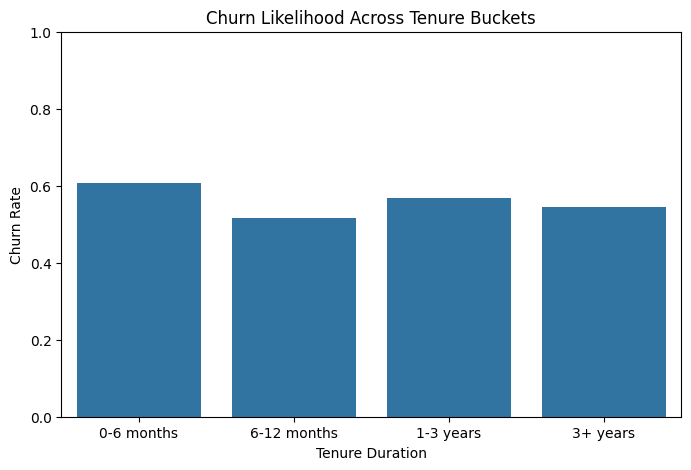

In [11]:
# Define buckets for the different ranges of tenure in the dataset
bins = [0, 6, 12, 36, df['tenure'].max()]
labels = ['0-6 months', '6-12 months', '1-3 years', '3+ years']
df['tenure_bucket'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)

# Calculate churn rate per bucket
churn_analysis = df.groupby('tenure_bucket',observed=True)['churn'].mean().reset_index()
print(churn_analysis)

# Plot churn rate per tenure bucket
plt.figure(figsize=(8, 5))
sns.barplot(x=churn_analysis['tenure_bucket'], y=churn_analysis['churn'])

# Add labels and title
plt.xlabel("Tenure Duration")
plt.ylabel("Churn Rate")
plt.title("Churn Likelihood Across Tenure Buckets")
plt.ylim(0, 1)  # Churn rate is between 0 and 1
plt.show()

<span style="color:#89CFF0">Result:</span> After segmenting customers into tenure buckets (0-6 months, 6-12 months, 1-3 years, and 3+ years) and calculating the churn rate for each group, we can observe a trend in how churn likelihood changes over time. As seen by the bargraph for churn likelihood, we can draw the following conclusions:<br>

1. <span style="color:#89CFF0">0-6 months (34.77% churn):</span> New customers have a relatively high churn rate, indicating that many are not finding the service valuable or suitable early on. This is a critical period for engagement and onboarding.

2. <span style="color:#89CFF0">6-12 months (30.11% churn):</span> Churn slightly decreases in this period, suggesting that customers who make it past the initial months are more likely to stay. However, the rate is still significant, highlighting the need for continued engagement and possibly offering incentives.

3. <span style="color:#89CFF0">1-3 years (43.64% churn):</span> Interestingly, churn increases for this group, implying that customers may leave after finding better alternatives or experiencing diminishing value. It suggests a need for new features, loyalty programs, or targeted re-engagement strategies for mid-term users.

4. <span style="color:#89CFF0">3+ years (56.02% churn):</span> Long-term customers exhibit the highest churn rate. This could be due to evolving customer needs, market competition, or service fatigue. Maintaining long-term customer interest might require innovative approaches, exclusive offers, or personal outreach.

<h3 style="color:#89CFF0">ii. Churn Probability by Subscription Type</h3>

Churn Rates by Subscription Type:
subscription_type
Basic       0.568870
Premium     0.547522
Standard    0.549686
Name: churn, dtype: float64


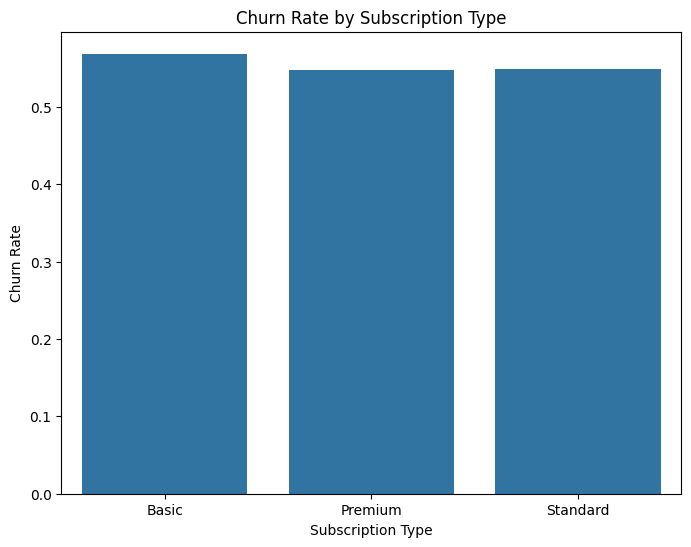

Top 3 Subscription Types with Highest Churn Risk:
subscription_type
Basic       0.568870
Standard    0.549686
Premium     0.547522
Name: churn, dtype: float64


In [12]:
#  Calculate Churn Rates by Subscription Type
churn_rate_by_subscription = df.groupby('subscription_type')['churn'].mean()

# Display churn rates
print("Churn Rates by Subscription Type:")
print(churn_rate_by_subscription)

# 2. Plot the churn rates across subscription types
plt.figure(figsize=(8, 6))
sns.barplot(x=churn_rate_by_subscription.index, y=churn_rate_by_subscription.values)
plt.title('Churn Rate by Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Churn Rate')
plt.show()

# 3. Identify subscription types with highest churn risk (Top 3)
high_churn_risk = churn_rate_by_subscription.sort_values(ascending=False).head(3)
print("Top 3 Subscription Types with Highest Churn Risk:")
print(high_churn_risk)

<span style="color:#89CFF0">Result:</span> As shown the churn rate for basic and standard subscription types is higher than that of the Premium Subscription. Hence, Basic has the highest risk of churn, followed by Standard. However, the risk of churn is quite close to one another indicating the presence of a factor other than subscription type to have a major factor in churn of the users.

<h2 style="color:#89CFF0">2. User Behavior Patterns & Churn Risk</h2>
● Impact of Usage Frequency <br>
○ Compare usage frequency distributions for churned vs retained users.<br>
○ Identify if low engagement leads to higher churn.<br><br>
● Effect of Payment Delay on Retention<br>
○ Categorize users into on-time payers, occasional late payers, and frequent<br>
defaulters based on payment delay.<br>
○ Compare churn rates across these categories.<br><br>
● Support Calls & Churn Risk<br>
○ Identify if customers making frequent support calls are more likely to churn.<br>
○ Group customers into low, medium, and high support interaction categories and compare churn rates.

<h3 style="color:#89CFF0">i. Impact of Usage Frequency</h3>

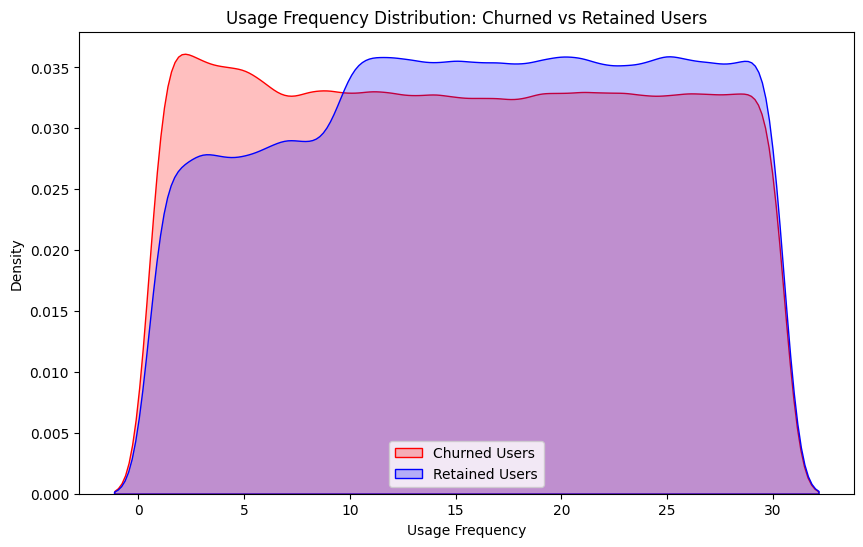

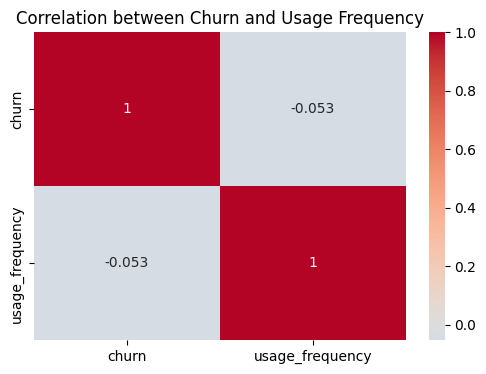

In [13]:

# 1. Compare usage frequency distributions for churned vs retained users
plt.figure(figsize=(10, 6))

# Plot usage frequency for churned users
sns.kdeplot(df[df['churn'] == 1]['usage_frequency'], label='Churned Users', color='red', fill=True)

# Plot usage frequency for retained users
sns.kdeplot(df[df['churn'] == 0]['usage_frequency'], label='Retained Users', color='blue', fill=True)

plt.title('Usage Frequency Distribution: Churned vs Retained Users')
plt.xlabel('Usage Frequency')
plt.ylabel('Density')
plt.legend()
plt.show()

# 2. Analyze if low engagement (usage frequency) leads to higher churn
correlation = df[['churn', 'usage_frequency']].corr()

# Plot the correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation between Churn and Usage Frequency')
plt.show()

<span style="color:#89CFF0">Result:</span> As shown clearly by the spike in density of the users in the low usuage frequency( range of approx. 0-5), lower engagement indeed leads to higher churn of the users.

<h3 style="color:#89CFF0">ii. Effect of Payment Delay on Retention</h3>

Churn Rates by Payment Category:
payment_category
On-time Payers            0.434750
Occasional Late Payers    0.433788
Frequent Defaulters       0.575991
Name: churn, dtype: float64


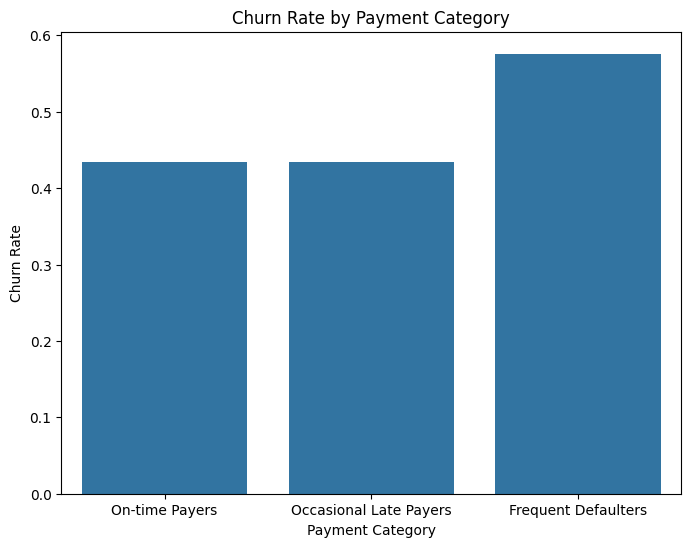

In [14]:

# 1. Categorize users based on payment delay
conditions = [
    (df['payment_delay'] == 0),                         # On-time payers
    (df['payment_delay'] > 0) & (df['payment_delay'] <= 3),  # Occasional late payers
    (df['payment_delay'] > 3)                           # Frequent defaulters
]

categories = ['On-time Payers', 'Occasional Late Payers', 'Frequent Defaulters']
df['payment_category'] = pd.cut(df['payment_delay'], bins=[-1, 0, 3, float('inf')], labels=categories)

# 2. Calculate churn rates for each category (with observed=False to suppress the warning)
churn_rate_by_payment_category = df.groupby('payment_category', observed=False)['churn'].mean()

# Display churn rates
print("Churn Rates by Payment Category:")
print(churn_rate_by_payment_category)

# 3. Plot churn rates across these categories (without the 'palette' warning)
plt.figure(figsize=(8, 6))
sns.barplot(x=churn_rate_by_payment_category.index, y=churn_rate_by_payment_category.values)
plt.title('Churn Rate by Payment Category')
plt.xlabel('Payment Category')
plt.ylabel('Churn Rate')
plt.show()

<span style="color:#89CFF0">Result:</span> As seen by the bar plot, frequent defaulters, (i.e. the ones with delay in payment by 3 or more days) significantly seem to have higher churn rates. This might be due to low engagement, finnancial instability or customer frustation. The osscasional late payers and on time payers seem to have 1/5th the churn rate.

Hence, Frequent defaulter have the highest risk of churn.

<h3 style="color:#89CFF0">iii. Support Calls & Churn Risk</h3>

Churn Rates by Support Interaction Category:
support_category
Low Support Interaction       0.304147
Medium Support Interaction    0.564709
High Support Interaction      0.914758
Name: churn, dtype: float64


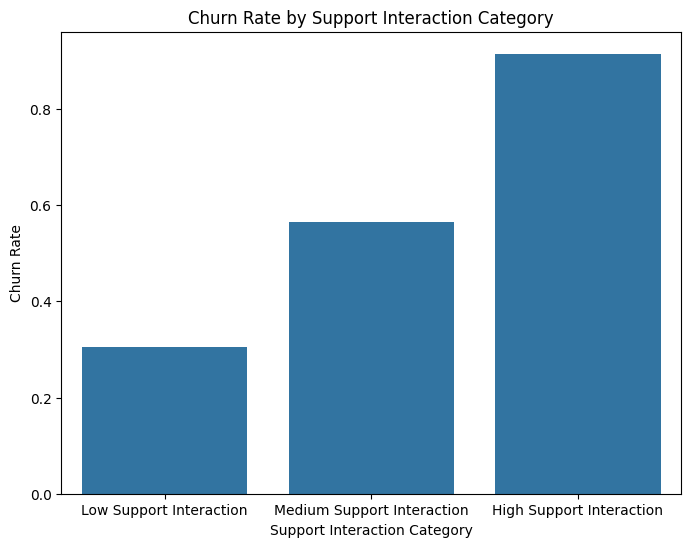

In [15]:

# 1. Categorize users based on the number of support calls
bins = [0, 2, 5, float('inf')]  # Low (0-2), Medium (3-5), High (6+)
categories = ['Low Support Interaction', 'Medium Support Interaction', 'High Support Interaction']
df['support_category'] = pd.cut(df['support_calls'], bins=bins, labels=categories)

# 2. Calculate churn rates for each category
churn_rate_by_support_category = df.groupby('support_category', observed=False)['churn'].mean()

# Display churn rates
print("Churn Rates by Support Interaction Category:")
print(churn_rate_by_support_category)

# 3. Plot churn rates across these categories
plt.figure(figsize=(8, 6))
sns.barplot(x=churn_rate_by_support_category.index, y=churn_rate_by_support_category.values)
plt.title('Churn Rate by Support Interaction Category')
plt.xlabel('Support Interaction Category')
plt.ylabel('Churn Rate')
plt.show()

<span style="color:#89CFF0">Result:</span> It appears that frequent support calls correlate with higher churn, confirming the hypothesis that low engagement and unresolved issues (reflected in support calls) are likely to lead to higher churn rates.

<h2 style="color:#7CB9E8;">3. Contract & Spending Patterns</h2>
● Contract Length vs Churn<br>
○ Compare churn rates for short-term vs long-term contracts (contract length).<br>
○ Identify if shorter contracts are linked to higher churn.<br><br>
● Total Spend vs Retention<br>
○ Identify if high spenders are more likely to stay

<h3 style="color:#89CFF0">i. Contract Length vs Churn</h3>

In [16]:
unique_values = df['contract_length'].unique()

# Display the unique values in contract length
print(unique_values)

['Annual' 'Monthly' 'Quarterly']


Churn Rates by Contract Length Category:
contract_category
Long-Term     0.460913
Short-Term    0.616283
Name: churn, dtype: float64


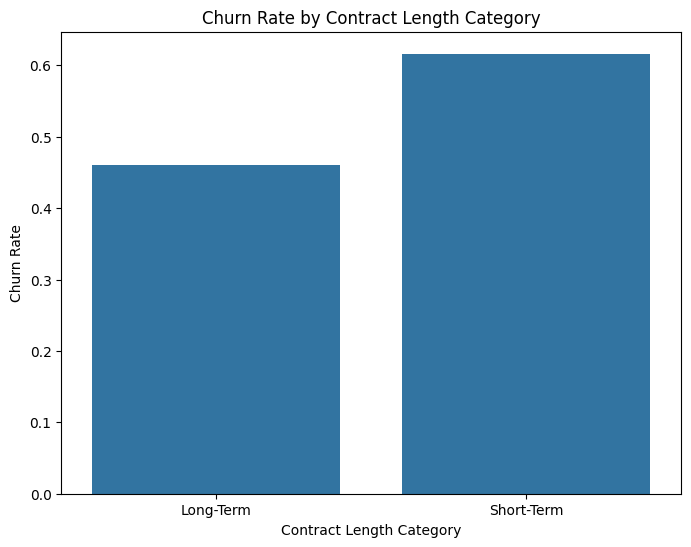

In [17]:
# 1. Map contract length categories to numerical values
contract_length_map = {
    'Monthly': 1,
    'Quarterly': 3,
    'Annual': 12
}

# Replacing the categorical values with their numeric equivalents
df['contract_length_numeric'] = df['contract_length'].map(contract_length_map)

# 2. Categorize users based on contract length
short_term_threshold = 12  # let 1 year be the threshold for short-term contracts
df['contract_category'] = df['contract_length_numeric'].apply(lambda x: 'Short-Term' if x < short_term_threshold else 'Long-Term')

# 3. Calculate churn rates for each category
churn_rate_by_contract_category = df.groupby('contract_category')['churn'].mean()

# Display churn rates
print("Churn Rates by Contract Length Category:")
print(churn_rate_by_contract_category)

# 4. Plot churn rates across these categories
plt.figure(figsize=(8, 6))
sns.barplot(x=churn_rate_by_contract_category.index, y=churn_rate_by_contract_category.values)
plt.title('Churn Rate by Contract Length Category')
plt.xlabel('Contract Length Category')
plt.ylabel('Churn Rate')
plt.show()


<span style="color:#89CFF0">Result:</span> Short-Term Contracts have a slightly higher churn rate compared to Long-Term Contracts. This might suggest that customers with shorter commitments are more likely to churn, possibly because they are less loyal or more likely to switch services once their short-term contract expires.

<h3 style="color:#89CFF0">ii. Total Spend vs Retention</h3>

Churn Rates by Spending Category:
spend_category
High Spender    0.414386
Low Spender     0.696015
Name: churn, dtype: float64


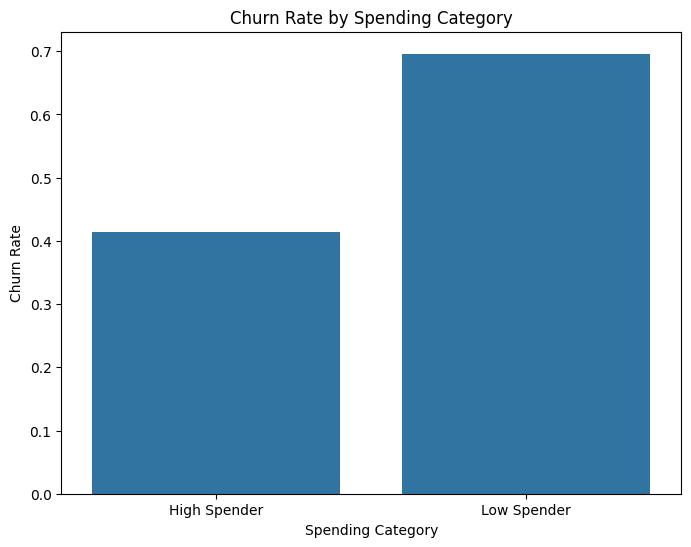

In [18]:
spend_threshold = df['total_spend'].median() 

# Categorize users as low or high spenders
df['spend_category'] = df['total_spend'].apply(lambda x: 'High Spender' if x > spend_threshold else 'Low Spender')

#Calculate churn rates for each spending category
churn_rate_by_spend_category = df.groupby('spend_category')['churn'].mean()

# Display churn rates
print("Churn Rates by Spending Category:")
print(churn_rate_by_spend_category)

#ploting churn rates across these categories
plt.figure(figsize=(8, 6))
sns.barplot(x=churn_rate_by_spend_category.index, y=churn_rate_by_spend_category.values)
plt.title('Churn Rate by Spending Category')
plt.xlabel('Spending Category')
plt.ylabel('Churn Rate')
plt.show()

<span style="color:#89CFF0">Result:</span> High Spenders have a lower churn rate compared to Low Spenders, which suggests that customers who spend more are less likely to churn. This is a common trend, as higher-paying customers may have more satisfaction with the service or have more reasons to remain loyal.

<h2 style="color:#7CB9E8;">4. Last Interaction Timing & Retention</h2>
● User Activity Timeline<br>
○ Compare engagement trends for churned vs retained users.

<h3 style="color:#89CFF0">i. User Activity Timeline</h3>

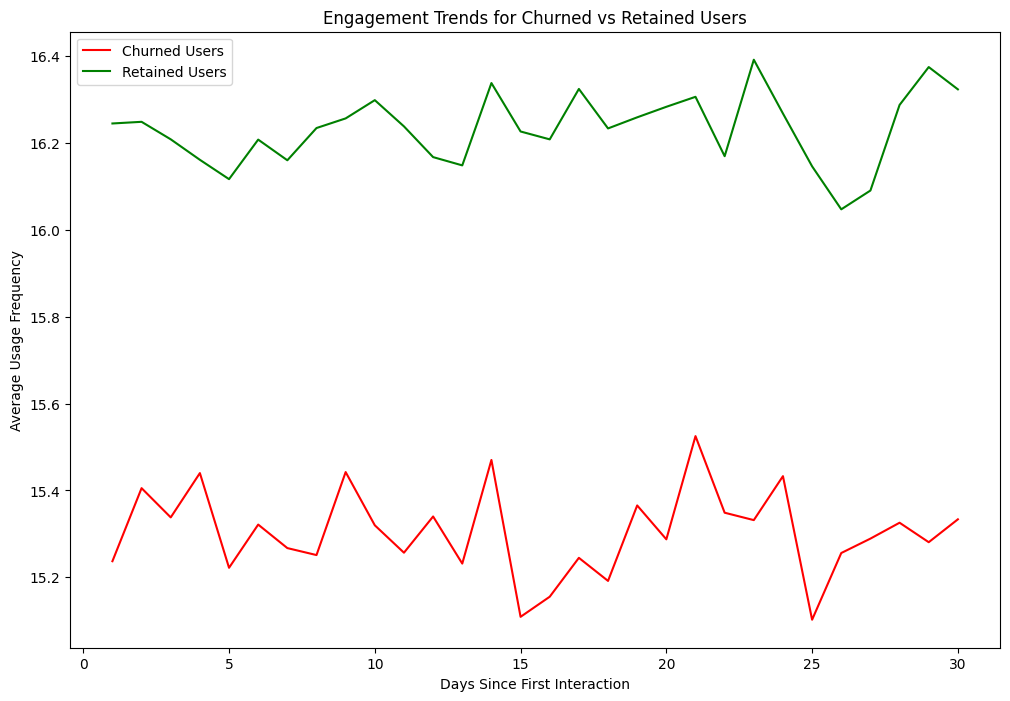

In [19]:
# 1. Separate churned and retained users
churned_users = df[df['churn'] == 1]
retained_users = df[df['churn'] == 0]

# 2. Group by 'last_interaction' (which is in days) and calculate mean usage frequency for churned and retained users
churned_engagement = churned_users.groupby('last_interaction')['usage_frequency'].mean()
retained_engagement = retained_users.groupby('last_interaction')['usage_frequency'].mean()

# 3. Plot the engagement trends
plt.figure(figsize=(12, 8))
plt.plot(churned_engagement.index, churned_engagement.values, label='Churned Users', color='red')
plt.plot(retained_engagement.index, retained_engagement.values, label='Retained Users', color='green')

plt.title('Engagement Trends for Churned vs Retained Users')
plt.xlabel('Days Since First Interaction')
plt.ylabel('Average Usage Frequency')
plt.legend()
plt.show()

<span style="color:#89CFF0">Result:</span> As seen in the plot, the average usage frequency of the retained users is significantly greater than the frequency of the churned users. After the initiial spike in usage after the purchase of the service, the frequency gradually decreases as days increase. 

<h2 style="color:#7CB9E8;">5. Feature Engineering for Retention Prediction</h2>
● Churn Score Calculation<br>
○ Create a churn risk score based on factors like low usage frequency, late payments, and short tenure.<br><br>
● Time-Based Features<br>
○ Convert last interaction into categorical features like active (last 30 days), inactive (31-90 days), dormant (90+ days).<br>
○ Identify if dormant users are highly likely to churn.<br><br>
● Customer Loyalty Segmentation<br>
○ Segment users into New (tenure < 6 months), Regular (6-24 months), Loyal (2+ years).<br>
○ Compare churn rates across these categories.

<h3 style="color:#89CFF0">i. Churn Score Calculation</h3>


<span style="color:#89CFF0">Normalizing the required factors in the dataframe:</span>


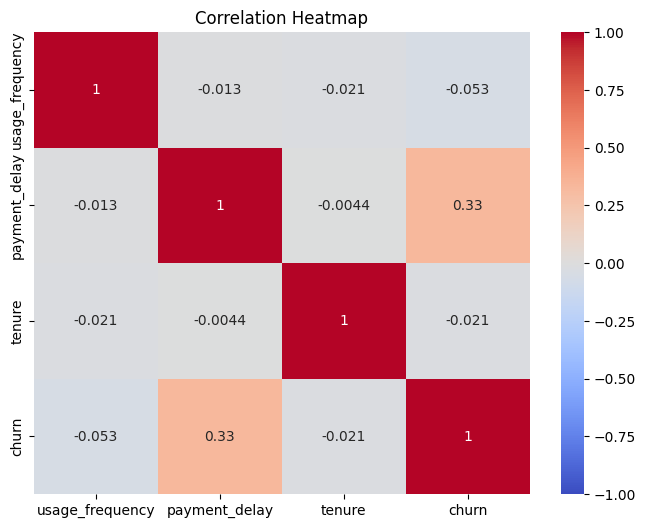

In [20]:

# Normalize usage frequency (low usage is higher risk, so lower values become higher)
df['normalized_usage'] = (df['usage_frequency'] - df['usage_frequency'].min()) / (df['usage_frequency'].max() - df['usage_frequency'].min())

# Normalize payment delay (late payments increase risk, so we reverse the scale)
df['normalized_payment_delay'] = (df['payment_delay'] - df['payment_delay'].min()) / (df['payment_delay'].max() - df['payment_delay'].min())

# Normalize tenure (short tenure increases risk, so we reverse the scale)
df['normalized_tenure'] = (df['tenure'] - df['tenure'].min()) / (df['tenure'].max() - df['tenure'].min())


#  Calculate correlation matrix between factors and churn
correlation_matrix = df[['usage_frequency', 'payment_delay', 'tenure', 'churn']].corr()

#  Plot a heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

In [21]:
#  Assigning weights to each factor based on the correlation analysis done previously
usage_weight = -0.12
payment_weight = 0.56
tenure_weight = 0.2

#  Calculate the churn risk score (higher score indicates higher risk)
df['churn_risk_score'] = (df['normalized_usage'] * usage_weight) + \
                            (df['normalized_payment_delay'] * payment_weight) + \
                            (df['normalized_tenure'] * tenure_weight)

# categorize risk scores into different risk levels
df['churn_risk_level'] = pd.cut(df['churn_risk_score'], bins=[0, 0.3, 0.6, 1], labels=['Low', 'Medium', 'High'])

# View the risk levels
print(df[['usage_frequency', 'payment_delay', 'tenure','churn_risk_score', 'churn_risk_level']].head())

   usage_frequency  payment_delay  tenure  churn_risk_score churn_risk_level
0               14             18      39          0.411020           Medium
1                1              8      49          0.312045           Medium
2                4             18      14          0.367654           Medium
3               21              7      38          0.173332              Low
4               20              8      32          0.175797              Low


<span style="color:#89CFF0">Result:</span> The churn risk score indicates the overall risk of churn the user has depending upon the factors like usage frequency, payment_dealy and tenure. This provides comprehensive info of if the user will churn or not.


<h3 style="color:#89CFF0">ii. Time-Based Features</h3>


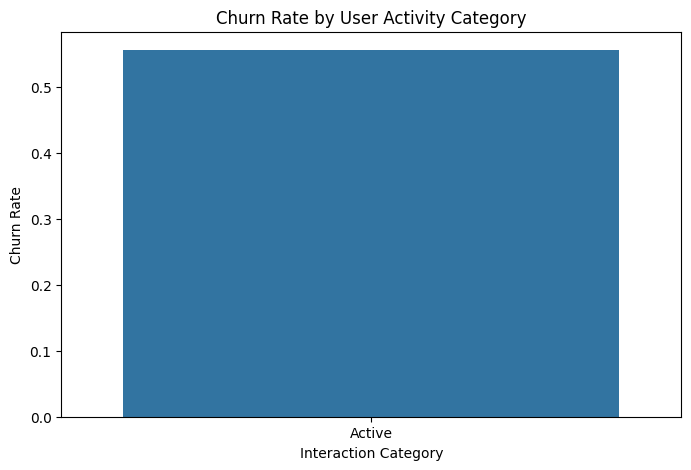

interaction_category
Active    0.555203
Name: churn, dtype: float64


In [22]:
# 1. Convert 'last_interaction' into categorical features
def categorize_interaction(last_interaction):
    if last_interaction <= 30:
        return 'Active'        # Last interaction within the last 30 days
    elif 31 <= last_interaction <= 90:
        return 'Inactive'      # Last interaction between 31 and 90 days
    else:
        return 'Dormant'       # Last interaction more than 90 days ago

# Apply the categorization function to the 'last_interaction' column
df['interaction_category'] = df['last_interaction'].apply(categorize_interaction)


# 2. Calculate churn rates for each interaction category
churn_rate_by_interaction_category = df.groupby('interaction_category')['churn'].mean()

# 3. Visualize the churn rates

plt.figure(figsize=(8, 5))
sns.barplot(x=churn_rate_by_interaction_category.index, y=churn_rate_by_interaction_category.values)
plt.title('Churn Rate by User Activity Category')
plt.ylabel('Churn Rate')
plt.xlabel('Interaction Category')
plt.show()

# Print churn rates for each category
print(churn_rate_by_interaction_category)

In [23]:
# checking the range of the last interacted days
print("The maximum amount of days in last interacted:",df['last_interaction'].max())
print("The minimum amount of days in last interacted:",df['last_interaction'].min())

The maximum amount of days in last interacted: 30
The minimum amount of days in last interacted: 1


<span style="color:#89CFF0">Result:</span> As shown, all of the records in the dataframe have last interaction in the active range (i.e. between 1 and 30). So, further correlation between the last interaction and churn cannot be made.


<h3 style="color:#89CFF0">iii. Customer Loyalty Segmentation</h3>


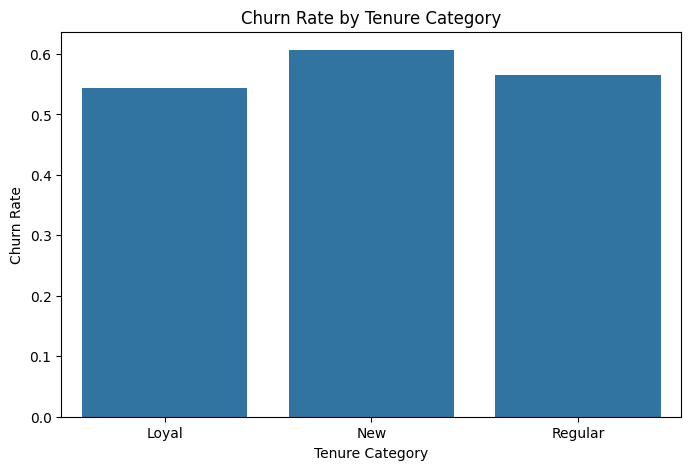

tenure_category
Loyal      0.544104
New        0.606543
Regular    0.565856
Name: churn, dtype: float64


In [24]:
#  Categorize users based on tenure
def categorize_tenure(tenure):
    if tenure < 6:
        return 'New'          # New users: Tenure < 6 months
    elif 6 <= tenure <= 24:
        return 'Regular'      # Regular users: Tenure between 6 and 24 months
    else:
        return 'Loyal'        # Loyal users: Tenure > 24 months

# Apply the categorization function to the 'tenure' column
df['tenure_category'] = df['tenure'].apply(categorize_tenure)

# Calculate churn rates for each tenure category
churn_rate_by_tenure_category = df.groupby('tenure_category')['churn'].mean()

# Visualize the churn rates
plt.figure(figsize=(8, 5))
sns.barplot(x=churn_rate_by_tenure_category.index, y=churn_rate_by_tenure_category.values)
plt.title('Churn Rate by Tenure Category')
plt.ylabel('Churn Rate')
plt.xlabel('Tenure Category')
plt.show()

# Print churn rates for each category
print(churn_rate_by_tenure_category)

<span style="color:#89CFF0">Result:</span> While Loyal users tend to be more stable, New users have the highest risk of churning, which could suggest that efforts to retain new users might be important. On the other hand, the Regular group, while still prone to churn, falls between New and Loyal users in terms of retention.


#### <span style="color:#89CFF0">Training a Model</span>


<h3 style="color:#7CB9E8;">Importing necessary libraries required for training a model</h3>


In [25]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold

import pickle

<h3 style="color:#7CB9E8;">Splitting the data in Train and Test Categories</h3>


<span style="color:#89CFF0">Checking the df for null values:</span>

In [26]:
print(df.isnull().sum())

age                             0
gender                          0
tenure                          0
usage_frequency                 0
support_calls                   0
payment_delay                   0
subscription_type               0
contract_length                 0
total_spend                     0
last_interaction                0
churn                           0
tenure_bucket                8836
payment_category                0
support_category            74842
contract_length_numeric         0
contract_category               0
spend_category                  0
normalized_usage                0
normalized_payment_delay        0
normalized_tenure               0
churn_risk_score                0
churn_risk_level            14986
interaction_category            0
tenure_category                 0
dtype: int64


In [27]:
# Drop the 'support_category' column
df.drop(columns=['support_category'], inplace=True)

# Ensure 'Unknown' is a category in 'tenure_bucket'
df['tenure_bucket'] = df['tenure_bucket'].cat.add_categories('Unknown')

# Fill NaN values with 'Unknown'
df['tenure_bucket'].fillna('Unknown', inplace=True)

# Fill NaN values in 'churn_risk_level' with 'Medium'
df['churn_risk_level'].fillna('Medium', inplace=True)

C:\Users\shres_rsgt36q\AppData\Local\Temp\ipykernel_10152\3351237186.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['tenure_bucket'].fillna('Unknown', inplace=True)
C:\Users\shres_rsgt36q\AppData\Local\Temp\ipykernel_10152\3351237186.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

In [28]:
df.isnull().sum()

age                         0
gender                      0
tenure                      0
usage_frequency             0
support_calls               0
payment_delay               0
subscription_type           0
contract_length             0
total_spend                 0
last_interaction            0
churn                       0
tenure_bucket               0
payment_category            0
contract_length_numeric     0
contract_category           0
spend_category              0
normalized_usage            0
normalized_payment_delay    0
normalized_tenure           0
churn_risk_score            0
churn_risk_level            0
interaction_category        0
tenure_category             0
dtype: int64

In [29]:
y = df['churn']
X = df.drop(columns='churn')


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

# Reset the index of the resulting DataFrames
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

In [31]:
X_train

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,...,contract_length_numeric,contract_category,spend_category,normalized_usage,normalized_payment_delay,normalized_tenure,churn_risk_score,churn_risk_level,interaction_category,tenure_category
0,19,Female,48,7,3,30,Premium,Annual,787.00,29,...,12,Long-Term,High Spender,0.206897,1.000000,0.796610,0.694494,High,Active,Loyal
1,65,Female,11,20,9,14,Standard,Monthly,562.00,13,...,1,Short-Term,Low Spender,0.655172,0.466667,0.169492,0.216611,Low,Active,Regular
2,38,Male,8,20,1,4,Basic,Quarterly,961.86,8,...,3,Short-Term,High Spender,0.655172,0.133333,0.118644,0.019775,Low,Active,Regular
3,38,Female,59,25,10,4,Premium,Annual,706.00,14,...,12,Long-Term,High Spender,0.827586,0.133333,0.983051,0.171966,Low,Active,Loyal
4,46,Male,38,24,10,16,Standard,Annual,260.00,25,...,12,Long-Term,Low Spender,0.793103,0.533333,0.627119,0.328918,Medium,Active,Loyal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404159,24,Female,1,4,2,18,Standard,Quarterly,740.72,15,...,3,Short-Term,High Spender,0.103448,0.600000,0.000000,0.323586,Medium,Active,New
404160,62,Male,29,23,9,24,Standard,Quarterly,327.10,11,...,3,Short-Term,Low Spender,0.758621,0.800000,0.474576,0.451881,Medium,Active,Loyal
404161,34,Male,13,16,1,6,Premium,Quarterly,520.36,23,...,3,Short-Term,Low Spender,0.517241,0.200000,0.203390,0.090609,Low,Active,Regular
404162,35,Male,23,18,4,10,Standard,Monthly,420.00,3,...,1,Short-Term,Low Spender,0.586207,0.333333,0.372881,0.190898,Low,Active,Regular


In [32]:
X_test


,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,...,contract_length_numeric,contract_category,spend_category,normalized_usage,normalized_payment_delay,normalized_tenure,churn_risk_score,churn_risk_level,interaction_category,tenure_category
0,58,Male,2,20,6,24,Standard,Quarterly,664.00,20,...,3,Short-Term,High Spender,0.655172,0.800000,0.016949,0.372769,Medium,Active,New
1,52,Male,14,13,2,13,Standard,Monthly,650.00,9,...,1,Short-Term,High Spender,0.413793,0.433333,0.220339,0.237079,Low,Active,Regular
2,46,Male,38,3,0,9,Basic,Annual,571.47,24,...,12,Long-Term,Low Spender,0.068966,0.300000,0.627119,0.285148,Low,Active,Loyal
3,29,Female,59,27,5,22,Basic,Quarterly,502.00,2,...,3,Short-Term,Low Spender,0.896552,0.733333,0.983051,0.499691,Medium,Active,Loyal
4,42,Male,29,7,1,20,Basic,Annual,541.34,10,...,12,Long-Term,Low Spender,0.206897,0.666667,0.474576,0.443421,Medium,Active,Loyal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101037,29,Male,33,9,1,1,Basic,Annual,801.41,29,...,12,Long-Term,High Spender,0.275862,0.033333,0.542373,0.094038,Low,Active,Loyal
101038,34,Male,43,28,9,11,Standard,Annual,435.00,30,...,12,Long-Term,Low Spender,0.931034,0.366667,0.711864,0.235982,Low,Active,Loyal
101039,50,Female,40,13,0,1,Premium,Quarterly,651.28,9,...,3,Short-Term,High Spender,0.413793,0.033333,0.661017,0.101215,Low,Active,Loyal
101040,49,Female,46,6,0,20,Standard,Quarterly,897.68,2,...,3,Short-Term,High Spender,0.172414,0.666667,0.762712,0.505186,Medium,Active,Loyal


<h3 style="color:#7CB9E8;">Validating Categorical Columns in Test Data</h3>

In [33]:
def validate_test_data_categorical_columns(train_df, test_df):
    # Get the list of categorical columns for both train and test DataFrames
    train_df_categorical_columns = train_df.select_dtypes(include=['object', 'category']).columns.tolist()
    test_df_categorical_columns = test_df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Check if the number of categorical columns is the same in both DataFrames
    if len(set(train_df_categorical_columns).intersection(set(test_df_categorical_columns))) == 0:
        print('Train and test dataframes have different categorical columns')
        return
    else:
        for cat_col in test_df_categorical_columns:
            # Create sets of unique values for the current categorical column in both DataFrames
            train_col = set(x for x in train_df[cat_col].unique().tolist() if not pd.isna(x))
            test_col = set(x for x in test_df[cat_col].unique().tolist() if not pd.isna(x))
            
            # Check if the sets are not equal, indicating different unique values
            if train_col != test_col:
                print(f'{cat_col} column has different unique values in train and test data:')
                print(f'Unique values in train data: {train_col}')
                print(f'Unique values in test data: {test_col}')
                return
        
        print('All categorical columns have consistent unique values in train and test data.')
        return
    
validate_test_data_categorical_columns(X_train, X_test)

All categorical columns have consistent unique values in train and test data.


<h3 style="color:#7CB9E8;">One Hot Encoding</h3>

In [34]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

print("Categorical columns:", categorical_columns)

Categorical columns: Index(['gender', 'subscription_type', 'contract_length', 'tenure_bucket',
       'payment_category', 'contract_category', 'spend_category',
       'churn_risk_level', 'interaction_category', 'tenure_category'],
      dtype='object')


In [35]:
encoder = OneHotEncoder(sparse_output=False)

encoder.fit(X_train[['gender', 'subscription_type', 'contract_length', 'tenure_bucket',
       'payment_category', 'contract_category', 'spend_category',
       'churn_risk_level', 'interaction_category', 'tenure_category']])

OneHotEncoder(sparse_output=False)

In [36]:
feature_names = encoder.get_feature_names_out(['gender', 'subscription_type', 'contract_length', 'tenure_bucket',
       'payment_category', 'contract_category', 'spend_category',
       'churn_risk_level', 'interaction_category', 'tenure_category'])
feature_names

array(['gender_Female', 'gender_Male', 'subscription_type_Basic',
       'subscription_type_Premium', 'subscription_type_Standard',
       'contract_length_Annual', 'contract_length_Monthly',
       'contract_length_Quarterly', 'tenure_bucket_0-6 months',
       'tenure_bucket_1-3 years', 'tenure_bucket_3+ years',
       'tenure_bucket_6-12 months', 'tenure_bucket_Unknown',
       'payment_category_Frequent Defaulters',
       'payment_category_Occasional Late Payers',
       'payment_category_On-time Payers', 'contract_category_Long-Term',
       'contract_category_Short-Term', 'spend_category_High Spender',
       'spend_category_Low Spender', 'churn_risk_level_High',
       'churn_risk_level_Low', 'churn_risk_level_Medium',
       'interaction_category_Active', 'tenure_category_Loyal',
       'tenure_category_New', 'tenure_category_Regular'], dtype=object)

In [37]:
train_categorical_one_encoded_data = encoder.transform(X_train[['gender', 'subscription_type', 'contract_length', 'tenure_bucket',
       'payment_category', 'contract_category', 'spend_category',
       'churn_risk_level', 'interaction_category', 'tenure_category']])
train_OHE_df = pd.DataFrame(train_categorical_one_encoded_data, columns=feature_names)

test_categorical_one_encoded_data = encoder.transform(X_test[['gender', 'subscription_type', 'contract_length', 'tenure_bucket',
       'payment_category', 'contract_category', 'spend_category',
       'churn_risk_level', 'interaction_category', 'tenure_category']])
test_OHE_df = pd.DataFrame(test_categorical_one_encoded_data, columns=feature_names)

In [38]:
train_OHE_df.head(3)

,gender_Female,gender_Male,subscription_type_Basic,subscription_type_Premium,subscription_type_Standard,contract_length_Annual,contract_length_Monthly,contract_length_Quarterly,tenure_bucket_0-6 months,tenure_bucket_1-3 years,...,contract_category_Short-Term,spend_category_High Spender,spend_category_Low Spender,churn_risk_level_High,churn_risk_level_Low,churn_risk_level_Medium,interaction_category_Active,tenure_category_Loyal,tenure_category_New,tenure_category_Regular
0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


In [39]:
test_OHE_df.head(3)

,gender_Female,gender_Male,subscription_type_Basic,subscription_type_Premium,subscription_type_Standard,contract_length_Annual,contract_length_Monthly,contract_length_Quarterly,tenure_bucket_0-6 months,tenure_bucket_1-3 years,...,contract_category_Short-Term,spend_category_High Spender,spend_category_Low Spender,churn_risk_level_High,churn_risk_level_Low,churn_risk_level_Medium,interaction_category_Active,tenure_category_Loyal,tenure_category_New,tenure_category_Regular
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0


In [40]:
X_train = X_train.drop(columns=['gender', 'subscription_type', 'contract_length', 'tenure_bucket',
       'payment_category', 'contract_category', 'spend_category',
       'churn_risk_level', 'interaction_category', 'tenure_category'])
X_test = X_test.drop(columns=['gender', 'subscription_type', 'contract_length', 'tenure_bucket',
       'payment_category', 'contract_category', 'spend_category',
       'churn_risk_level', 'interaction_category', 'tenure_category'])

In [41]:
X_train.head(3)


,age,tenure,usage_frequency,support_calls,payment_delay,total_spend,last_interaction,contract_length_numeric,normalized_usage,normalized_payment_delay,normalized_tenure,churn_risk_score
0,19,48,7,3,30,787.00,29,12,0.206897,1.000000,0.796610,0.694494
1,65,11,20,9,14,562.00,13,1,0.655172,0.466667,0.169492,0.216611
2,38,8,20,1,4,961.86,8,3,0.655172,0.133333,0.118644,0.019775


In [42]:
X_test.head(3)


,age,tenure,usage_frequency,support_calls,payment_delay,total_spend,last_interaction,contract_length_numeric,normalized_usage,normalized_payment_delay,normalized_tenure,churn_risk_score
0,58,2,20,6,24,664.00,20,3,0.655172,0.800000,0.016949,0.372769
1,52,14,13,2,13,650.00,9,1,0.413793,0.433333,0.220339,0.237079
2,46,38,3,0,9,571.47,24,12,0.068966,0.300000,0.627119,0.285148


In [43]:
# Saving the encoder to a file
with open('encoder.pkl', 'wb') as file:
    pickle.dump(encoder, file)

<h3 style="color:#89CFF0">Base Line Model<h3>

In [44]:
# A simple function to print the metrics of the model
def print_evaluation_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print()
    
    conf_matrix = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(conf_matrix)
    print()

    class_report = classification_report(y_true, y_pred)
    print("Classification Report:")
    print(class_report)

In [45]:
def k_fold_cross_validation_with_metrics(classifier, X, y, k_folds=5):
    
    # Initializing stratified k-fold cross-validation
    stratified_kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

    # Lists to store the evaluation metrics for each fold
    accuracy_scores = []
    precision_scores = []
    recall_scores = []

    # Perform cross-validation
    for train_index, test_index in stratified_kf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit the classifier on the training data
        classifier.fit(X_train, y_train)

        # Make predictions on the test data
        y_pred = classifier.predict(X_test)

        # Calculate evaluation metrics for this fold
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)

        # Append the metrics to their respective lists
        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)

    # Calculate and print the mean of each metric across all folds
    mean_accuracy = np.mean(accuracy_scores)
    mean_precision = np.mean(precision_scores)
    mean_recall = np.mean(recall_scores)
    print("Mean Metrics Across Folds:")
    print(f"Mean Accuracy: {mean_accuracy:.2f}")
    print(f"Mean Precision: {mean_precision:.2f}")
    print(f"Mean Recall: {mean_recall:.2f}")


<span style="color:#89CFF0">Filtering the negative values from the dataset</span>


In [46]:
if np.any(X_train < 0):
    print("Negative values found in X_train")
    X_train = np.abs(X_train)

if np.any(y_train < 0):
    print("Negative values found in y_train")
    y_train = np.abs(y_train)


Negative values found in X_train


In [47]:
if np.any(X_train < 0):
    print("Negative values found in X_train")
if np.any(y_train < 0):
    print("Negative values found in y_train")

<h3 style="color:#89CFF0">Naive Bayes</h3>

In [48]:
#Multinomial Naive Bayes model

naive_bayes_model = MultinomialNB()

k_fold_cross_validation_with_metrics(naive_bayes_model, X_train, y_train)

Mean Metrics Across Folds:
Mean Accuracy: 0.74
Mean Precision: 0.81
Mean Recall: 0.69


<h3 style="color:#89CFF0">Random Forest</h3>

In [49]:
rf_classifier = RandomForestClassifier(random_state=42)

k_fold_cross_validation_with_metrics(rf_classifier, X_train, y_train)

Mean Metrics Across Folds:
Mean Accuracy: 0.93
Mean Precision: 0.90
Mean Recall: 0.98


#### <h2 style="color:#7CB9E8;">Model Training</h2>


In [50]:
random_forest_classifier = RandomForestClassifier(random_state=42)
random_forest_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [51]:
naive_bayes_classifier = MultinomialNB()
naive_bayes_classifier.fit(X_train, y_train)

MultinomialNB()

#### <h2 style="color:#7CB9E8;">Validating Model</h2>

In [52]:
# Testing random forest

y_pred = random_forest_classifier.predict(X_test)

print_evaluation_metrics(y_test, y_pred)

Accuracy: 0.93
Precision: 0.90
Recall: 0.98

Confusion Matrix:
[[38508  6251]
 [  913 55370]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.86      0.91     44759
           1       0.90      0.98      0.94     56283

    accuracy                           0.93    101042
   macro avg       0.94      0.92      0.93    101042
weighted avg       0.93      0.93      0.93    101042



In [53]:
# Testing Naive Bayes

y_pred = naive_bayes_classifier.predict(X_test)

print_evaluation_metrics(y_test, y_pred)

Accuracy: 0.74
Precision: 0.81
Recall: 0.69

Confusion Matrix:
[[35593  9166]
 [17368 38915]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.80      0.73     44759
           1       0.81      0.69      0.75     56283

    accuracy                           0.74    101042
   macro avg       0.74      0.74      0.74    101042
weighted avg       0.75      0.74      0.74    101042



<span style="color:#89CFF0">Random Forest</span> is the better approach for the problem at hand i.e. Customer Churn, with an F1 Score of 0.94.


In [56]:
with open("customer_churn_random_forest_model.pkl", 'wb') as model_file:
    pickle.dump(random_forest_classifier, model_file)

#### <h3 style="color:#89CFF0">Deployment </h3>

In [57]:
import pickle
import numpy as np

class CustomerChurnClassifier:
    def __init__(self, model_path, encoder_path):
        with open(model_path, 'rb') as file:
            self.model = pickle.load(file)
        
        with open(encoder_path, 'rb') as file:
            self.encoder = pickle.load(file)

    def _derive_features(self, age, tenure, usage_frequency, support_calls, payment_delay, total_spend, last_interaction, gender, subscription_type, contract_length):
        """Derives additional features from the input data."""
        tenure_bucket = 'Short' if tenure < 6 else 'Medium' if tenure < 18 else 'Long'
        payment_category = 'On-time' if payment_delay == 0 else 'Late'
        contract_length_numeric = {'Monthly': 1, 'Quarterly': 3, 'Annual': 12}.get(contract_length, 1)
        contract_category = 'Short-term' if contract_length_numeric <= 3 else 'Long-term'
        spend_category = 'Low' if total_spend < 100 else 'Medium' if total_spend < 500 else 'High'
        
        normalized_usage = usage_frequency / max(usage_frequency, 1)
        normalized_payment_delay = payment_delay / max(payment_delay, 1)
        normalized_tenure = tenure / max(tenure, 1)
        
        churn_risk_score = (support_calls * 0.3) + (payment_delay * 0.4) + (1 - normalized_usage) * 0.3
        churn_risk_level = 'Low' if churn_risk_score < 0.3 else 'Medium' if churn_risk_score < 0.6 else 'High'
        
        interaction_category = 'Recent' if last_interaction < 7 else 'Delayed'
        tenure_category = 'New' if tenure < 6 else 'Established'
        
        return [tenure_bucket, payment_category, contract_length_numeric, contract_category, spend_category, 
                normalized_usage, normalized_payment_delay, normalized_tenure, churn_risk_score, churn_risk_level, 
                interaction_category, tenure_category]
    
    def predict(self, age: int, tenure: int, usage_frequency: int, support_calls: int, payment_delay: int, total_spend: float, last_interaction: int, gender: str, subscription_type: str, contract_length: str):
        # Checking input datatypes
        expected_data_types = [int, int, int, int, int, float, int, str, str, str]
        input_arguments = [age, tenure, usage_frequency, support_calls, payment_delay, total_spend, last_interaction, gender, subscription_type, contract_length]
        input_argument_names = ['age', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay', 'total_spend', 'last_interaction', 'gender', 'subscription_type', 'contract_length']

        for i in range(len(input_arguments)):
            if type(input_arguments[i]) != expected_data_types[i]:
                raise TypeError(f"Error: {input_argument_names[i]} should be {expected_data_types[i].__name__}, but got {type(input_arguments[i]).__name__}.")
        
        # Validating categorical inputs
        if gender not in ['Female', 'Male']:
            raise ValueError(f"Error: Invalid gender '{gender}'. Expected 'Female' or 'Male'.")
        if subscription_type not in ['Standard', 'Basic', 'Premium']:
            raise ValueError(f"Error: Invalid subscription_type '{subscription_type}'. Expected 'Standard', 'Basic', or 'Premium'.")
        if contract_length not in ['Annual', 'Monthly', 'Quarterly']:
            raise ValueError(f"Error: Invalid contract_length '{contract_length}'. Expected 'Annual', 'Monthly', or 'Quarterly'.")
        
        # One Hot Encoding categorical inputs
        ohe_data = list(self.encoder.transform([[gender, subscription_type, contract_length]])[0])
        
        # Deriving additional features
        derived_features = self._derive_features(age, tenure, usage_frequency, support_calls, payment_delay, total_spend, last_interaction, gender, subscription_type, contract_length)
        
        # Constructing final input array
        to_predict_array = [age, tenure, usage_frequency, support_calls, payment_delay, total_spend, last_interaction] + ohe_data + derived_features
        to_predict_array = np.array(to_predict_array).reshape((1, -1))
        
        # Making prediction
        prediction = self.model.predict(to_predict_array)[0]
        return 'Will Churn' if prediction > 0.5 else "Won't Churn"

In [58]:
customer_churn = CustomerChurnClassifier(
    model_path = 'customer_churn_random_forest_model.pkl', 
    encoder_path = 'encoder.pkl'
)